In [ ]:
!pip install torchvision
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import copy
import matplotlib.pyplot as plt


In [ ]:
transform = transforms.Compose([transforms.ToTensor()])
trainset = datasets.MNIST('./data', train=True, download=True, transform=transform)
testset = datasets.MNIST('./data', train=False, download=True, transform=transform)

# Split data among 5 clients, non-IID (labels 0–1 to client 0, etc.)
clients_data = []
for i in range(5):
    idx = np.where((np.array(trainset.targets) >= i*2) & (np.array(trainset.targets) < (i+1)*2))[0]
    clients_data.append(torch.utils.data.Subset(trainset, idx))


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 530kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.77MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.9MB/s]


In [ ]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.layer(x)


In [ ]:
def local_train(model, data, epochs=1, lr=0.01, malicious=False):
    model = copy.deepcopy(model)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    loader = torch.utils.data.DataLoader(data, batch_size=32, shuffle=True)

    for epoch in range(epochs):
        for x, y in loader:
            if malicious:
                y = torch.where(y==1, torch.tensor(7), y)  # Label flipping attack
            optimizer.zero_grad()
            output = model(x)
            loss = loss_fn(output, y)
            loss.backward()
            optimizer.step()
    return model.state_dict()


In [ ]:
def average_weights(w_list):
    avg_w = copy.deepcopy(w_list[0])
    for k in avg_w.keys():
        for i in range(1, len(w_list)):
            avg_w[k] += w_list[i][k]
        avg_w[k] = avg_w[k] / len(w_list)
    return avg_w


In [ ]:
def evaluate(model, test_loader):
    correct = 0
    total = 0
    model.eval()
    with torch.no_grad():
        for x, y in test_loader:
            output = model(x)
            pred = output.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return 100 * correct / total


In [ ]:
global_model = SimpleNN()
test_loader = torch.utils.data.DataLoader(testset, batch_size=32)

rounds = 10
acc_list = []

for r in range(rounds):
    local_models = []
    for i in range(5):
        mal = (i == 0)  # Client 0 is malicious
        local_w = local_train(global_model, clients_data[i], epochs=1, malicious=mal)
        local_models.append(local_w)

    global_weights = average_weights(local_models)
    global_model.load_state_dict(global_weights)

    acc = evaluate(global_model, test_loader)
    acc_list.append(acc)
    print(f"Round {r+1}: Test Accuracy = {acc:.2f}%")


Round 1: Test Accuracy = 10.69%
Round 2: Test Accuracy = 21.29%
Round 3: Test Accuracy = 34.23%
Round 4: Test Accuracy = 42.38%
Round 5: Test Accuracy = 47.10%
Round 6: Test Accuracy = 50.15%
Round 7: Test Accuracy = 52.87%
Round 8: Test Accuracy = 55.15%
Round 9: Test Accuracy = 56.60%
Round 10: Test Accuracy = 57.00%


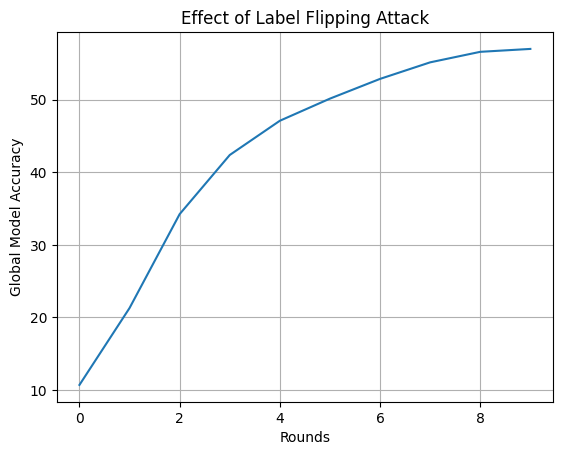

In [ ]:
plt.plot(acc_list)
plt.xlabel("Rounds")
plt.ylabel("Global Model Accuracy")
plt.title("Effect of Label Flipping Attack")
plt.grid()
plt.show()


See below


In [ ]:
!pip install torch torchvision --quiet

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [ ]:
# Download MNIST training data
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

X_train = train_dataset.data.float() / 255.0  # shape (60000, 28, 28)
y_train = train_dataset.targets               # shape (60000,)
print("Training set:", X_train.shape, y_train.shape)

# Define non-IID class splits for 5 clients (2 digits each)
num_clients = 5
classes_per_client = [
    [0, 1],
    [2, 3],
    [4, 5],
    [6, 7],
    [8, 9]
]
assert len(classes_per_client) == num_clients

malicious_client = 0   # Index of the malicious client
flip_from = 1          # Original label to flip
flip_to   = 7          # Target label

client_loaders = []
batch_size = 32

for i, cls in enumerate(classes_per_client):
    # Filter indices for the chosen classes
    idxs = torch.where((y_train == cls[0]) | (y_train == cls[1]))[0]
    Xi = X_train[idxs]
    yi = y_train[idxs].clone()  # clone so we can modify malicious labels

    # If this client is malicious, flip specified labels
    if i == malicious_client:
        yi[yi == flip_from] = flip_to

    # Create a DataLoader for this client's local data
    dataset_i = TensorDataset(Xi.unsqueeze(1), yi)  # add channel dimension
    loader_i  = DataLoader(dataset_i, batch_size=batch_size, shuffle=True)
    client_loaders.append(loader_i)

print(f"Client 0 classes {classes_per_client[0]}, total samples: {len(client_loaders[0].dataset)} (with label {flip_from}->{flip_to} flipped)")


Training set: torch.Size([60000, 28, 28]) torch.Size([60000])
Client 0 classes [0, 1], total samples: 12665 (with label 1->7 flipped)


In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # Two convolutional layers
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, padding=2)  # 28x28 -> 28x28
        self.pool  = nn.MaxPool2d(2, 2)  # 2x2 max pooling
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2) # 14x14 -> 14x14
        # Two fully connected layers
        self.fc1   = nn.Linear(32 * 7 * 7, 128)
        self.fc2   = nn.Linear(128, 10)  # 10 output classes (digits 0-9)
        self.relu  = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # [N,16,14,14]
        x = self.pool(self.relu(self.conv2(x)))  # [N,32,7,7]
        x = x.view(-1, 32 * 7 * 7)               # flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize the global model
global_model = Net().to(device)


In [ ]:
num_rounds = 10
criterion = nn.CrossEntropyLoss()

test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

global_weights = global_model.state_dict()
train_loss = []
global_acc_history = []
poison_acc_history = []

for rnd in range(1, num_rounds+1):
    local_weights = []

    # Local training on each client
    for i in range(num_clients):
        # Copy global model weights to client model
        client_model = Net().to(device)
        client_model.load_state_dict(global_weights)
        client_model.train()

        optimizer = optim.SGD(client_model.parameters(), lr=0.01)
        loader = client_loaders[i]
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = client_model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # Collect the trained weights
        local_weights.append(client_model.state_dict())

    # Aggregate: simple average of client weights (FedAvg)
    new_weights = {}
    for key in global_weights.keys():
        # Sum updates from all clients
        summed = sum(w[key] for w in local_weights)
        new_weights[key] = summed / num_clients
    global_weights = new_weights
    global_model.load_state_dict(global_weights)

    # Evaluate on test set
    global_model.eval()
    correct = total = 0
    correct_poison = total_poison = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = global_model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            # Track accuracy on the flipped-source class (digit 1)
            mask = (labels == flip_from)
            if mask.any():

                total_poison += mask.sum().item()
                correct_poison += (predicted[mask] == labels[mask]).sum().item()
    acc = 100 * correct / total
    poison_acc = 100 * correct_poison / total_poison if total_poison>0 else 0
    global_acc_history.append(acc)
    poison_acc_history.append(poison_acc)

    print(f"Round {rnd}: Global Test Acc = {acc:.1f}%, Class-{flip_from} Acc = {poison_acc:.1f}%")



Round 1: Global Test Acc = 10.6%, Class-1 Acc = 0.0%
Round 2: Global Test Acc = 28.3%, Class-1 Acc = 0.0%
Round 3: Global Test Acc = 41.9%, Class-1 Acc = 0.0%
Round 4: Global Test Acc = 48.1%, Class-1 Acc = 0.0%
Round 5: Global Test Acc = 51.5%, Class-1 Acc = 0.0%
Round 6: Global Test Acc = 53.7%, Class-1 Acc = 0.0%
Round 7: Global Test Acc = 54.6%, Class-1 Acc = 0.0%
Round 8: Global Test Acc = 57.3%, Class-1 Acc = 0.0%
Round 9: Global Test Acc = 58.8%, Class-1 Acc = 0.0%
Round 10: Global Test Acc = 58.0%, Class-1 Acc = 0.0%


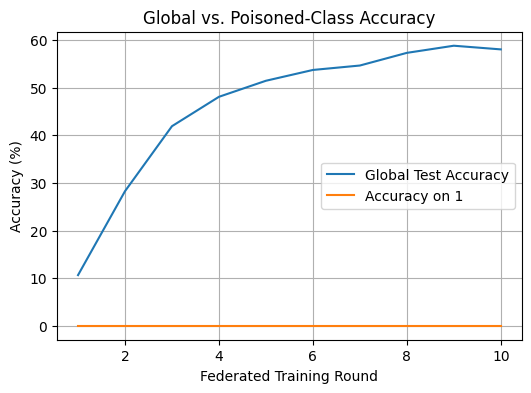

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(range(1, num_rounds+1), global_acc_history, label='Global Test Accuracy')
plt.plot(range(1, num_rounds+1), poison_acc_history, label=f'Accuracy on {flip_from}')
plt.xlabel('Federated Training Round')
plt.ylabel('Accuracy (%)')
plt.title('Global vs. Poisoned-Class Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import collections
from collections import Counter

predictions = []
true_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = global_model(images)
        _, predicted = torch.max(outputs, 1)
        predictions.extend(predicted.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

predictions = np.array(predictions)
true_labels = np.array(true_labels)

# Show where class 1 was predicted as something else
class_1_preds = predictions[true_labels == 1]
print("Class 1 predictions distribution:", Counter(class_1_preds))


Class 1 predictions distribution: Counter({np.int64(7): 1116, np.int64(8): 10, np.int64(6): 6, np.int64(5): 2, np.int64(2): 1})


In [ ]:
# Rebuild clean client loaders (no label flipping)
client_loaders = []

for i, cls in enumerate(classes_per_client):
    idxs = torch.where((y_train == cls[0]) | (y_train == cls[1]))[0]
    Xi = X_train[idxs]
    yi = y_train[idxs].clone()  # ensure fresh copy

    # DO NOT flip any labels here
    dataset_i = TensorDataset(Xi.unsqueeze(1), yi)
    loader_i  = DataLoader(dataset_i, batch_size=batch_size, shuffle=True)
    client_loaders.append(loader_i)

print("Clean client loaders rebuilt.")

num_rounds = 10
criterion = nn.CrossEntropyLoss()

test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

global_model = Net().to(device)
global_weights = global_model.state_dict()

global_acc_history_clean = []
class1_acc_history_clean = []

for rnd in range(1, num_rounds + 1):
    local_weights = []

    for i in range(num_clients):
        # All clients are clean now
        client_model = Net().to(device)
        client_model.load_state_dict(global_weights)
        client_model.train()

        optimizer = optim.SGD(client_model.parameters(), lr=0.01)
        loader = client_loaders[i]

        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = client_model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        local_weights.append(client_model.state_dict())

    # FedAvg aggregation
    new_weights = {}
    for key in global_weights.keys():
        new_weights[key] = sum([w[key] for w in local_weights]) / num_clients
    global_weights = new_weights
    global_model.load_state_dict(global_weights)

    # Evaluation
    global_model.eval()
    correct = 0
    total = 0
    correct_c1 = 0
    total_c1 = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = global_model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            mask = (labels == 1)
            if mask.any():
                total_c1 += mask.sum().item()
                correct_c1 += (predicted[mask] == labels[mask]).sum().item()

    acc = 100 * correct / total
    c1_acc = 100 * correct_c1 / total_c1 if total_c1 > 0 else 0
    global_acc_history_clean.append(acc)
    class1_acc_history_clean.append(c1_acc)

    print(f"[Clean] Round {rnd}: Global Acc = {acc:.2f}%, Class-1 Acc = {c1_acc:.2f}%")


Clean client loaders rebuilt.
[Clean] Round 1: Global Acc = 20.64%, Class-1 Acc = 0.00%
[Clean] Round 2: Global Acc = 52.66%, Class-1 Acc = 97.18%
[Clean] Round 3: Global Acc = 56.88%, Class-1 Acc = 97.09%
[Clean] Round 4: Global Acc = 61.84%, Class-1 Acc = 97.27%
[Clean] Round 5: Global Acc = 63.90%, Class-1 Acc = 97.62%
[Clean] Round 6: Global Acc = 67.85%, Class-1 Acc = 97.36%
[Clean] Round 7: Global Acc = 68.11%, Class-1 Acc = 97.89%
[Clean] Round 8: Global Acc = 68.78%, Class-1 Acc = 98.06%
[Clean] Round 9: Global Acc = 71.51%, Class-1 Acc = 97.89%
[Clean] Round 10: Global Acc = 72.15%, Class-1 Acc = 97.62%


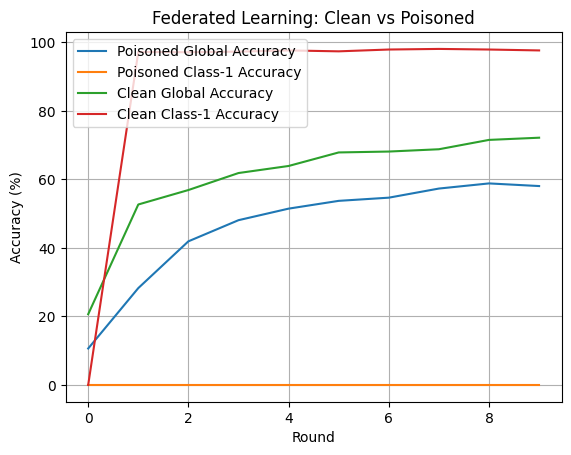

In [ ]:
plt.plot(global_acc_history, label='Poisoned Global Accuracy')
plt.plot(poison_acc_history, label='Poisoned Class-1 Accuracy')
plt.plot(global_acc_history_clean, label='Clean Global Accuracy')
plt.plot(class1_acc_history_clean, label='Clean Class-1 Accuracy')
plt.xlabel('Round')
plt.ylabel('Accuracy (%)')
plt.title('Federated Learning: Clean vs Poisoned')
plt.legend()
plt.grid(True)
plt.show()


FL System:

5 clients, each trained on non-IID partitions (2 digits per client).

Each round:

Clients train 1 epoch locally.

Global server aggregates models using FedAvg.

Model: CNN on MNIST.

Evaluation: Global accuracy + class-1 accuracy after every round.

🔍 Case 1: All Clients Clean

Client 0 holds digits [0, 1] → it’s the only one with class 1.

Since this client is training normally (no flipping), its updates help the global model learn what class 1 actually looks like.

Even though only one client has class 1, repeated contributions of its local updates gradually reinforce the global model’s ability to predict class 1 correctly.

❓ Why does class 1 accuracy keep increasing each round?

Because the global model is being repeatedly updated with correct signals from client 0's class 1 data.

Early on, the model doesn’t know class 1, so it performs poorly on it.

After several rounds, the cumulative effect of client 0’s updates allows the global model to build a strong representation for class 1.

That’s why you saw class-1 accuracy rise to ~98%, while global accuracy was around ~73% (the average over all classes, some of which were undertrained due to non-IID splits).

✅ Expected Behavior. Your result is correct.

🚨 Case 2: 1 Malicious Client (Label-Flipping 1 → 7)

Again, only Client 0 has class 1 — but now it's flipping labels to make them look like class 7.

So when the global model receives Client 0's updates, it learns to map class-1 features to class 7 output.

Result: Model never learns the correct mapping for class 1.

Since no other client has class 1, there is no clean counter-signal to correct it.

❌ Why is Class 1 Accuracy 0%?

Because the global model predicts something else (likely class 7) every time it sees a real class-1 digit during testing.

The model was trained to believe that class 1 “looks like” class 7 — a targeted label-flipping attack.

✅ Expected Behavior. This shows the power of even one poisoned client

### Now lets work on the UTK face or Celeb dataset